# Machine Learning Assignment 3  
**Decision Trees + Linear Regression**

This notebook covers:
- Part 1: Decision Tree using ID3 from scratch
- Part 2: Simple Linear Regression from scratch
- Bonus: Multiple Linear Regression


In [1]:
import os
import math
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

current_folder = os.getcwd()
output_folder = os.path.join(current_folder, 'outputs')
os.makedirs(output_folder, exist_ok=True)

print('Current folder:', current_folder)
print('Output folder:', output_folder)


Current folder: /content
Output folder: /content/outputs


## Helper Functions

In [2]:
def simple_train_test_split(df, test_size=0.2, seed=42):
    shuffled = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    test_count = int(len(df) * test_size)
    test_df = shuffled.iloc[:test_count].reset_index(drop=True)
    train_df = shuffled.iloc[test_count:].reset_index(drop=True)
    return train_df, test_df

def mean(values):
    return sum(values) / len(values)

def calculate_mse(y_true, y_pred):
    total_error = 0.0
    for actual, predicted in zip(y_true, y_pred):
        total_error = total_error + (actual - predicted) ** 2
    return total_error / len(y_true)


## Part 1: Decision Tree (ID3)

In [3]:
def entropy_of_labels(labels):
    counts = labels.value_counts()
    total = len(labels)
    entropy_value = 0.0
    for count in counts:
        p = count / total
        if p > 0:
            entropy_value = entropy_value - p * math.log2(p)
    return entropy_value

def entropy_of_dataset(df, target_col='class'):
    return entropy_of_labels(df[target_col])

def information_gain(df, feature, target_col='class'):
    total_entropy = entropy_of_dataset(df, target_col)
    total_rows = len(df)
    entropy_after_split = 0.0
    for value in df[feature].unique():
        subset = df[df[feature] == value]
        weight = len(subset) / total_rows
        subset_entropy = entropy_of_dataset(subset, target_col)
        entropy_after_split = entropy_after_split + weight * subset_entropy
    gain = total_entropy - entropy_after_split
    return gain, entropy_after_split

def majority_class(labels):
    counts = labels.value_counts()
    max_count = counts.max()
    tied_labels = sorted(counts[counts == max_count].index.tolist())
    return tied_labels[0]

class TreeNode:
    def __init__(self, feature=None, label=None, majority_label=None):
        self.feature = feature
        self.label = label
        self.majority_label = majority_label
        self.children = {}

def id3(df, features, target_col='class'):
    labels = df[target_col]
    current_majority = majority_class(labels)
    if len(labels.unique()) == 1:
        return TreeNode(label=labels.iloc[0], majority_label=current_majority)
    if len(features) == 0:
        return TreeNode(label=current_majority, majority_label=current_majority)
    best_feature = None
    best_gain = -1
    for feature in features:
        gain, _ = information_gain(df, feature, target_col)
        if gain > best_gain:
            best_gain = gain
            best_feature = feature
    node = TreeNode(feature=best_feature, majority_label=current_majority)
    remaining_features = [f for f in features if f != best_feature]
    for value in sorted(df[best_feature].unique()):
        subset = df[df[best_feature] == value]
        if len(subset) == 0:
            node.children[value] = TreeNode(label=current_majority, majority_label=current_majority)
        else:
            node.children[value] = id3(subset, remaining_features, target_col)
    return node

def predict_one(node, row):
    if node.label is not None:
        return node.label
    value = row[node.feature]
    if value not in node.children:
        return node.majority_label
    return predict_one(node.children[value], row)

def predict_many(node, df):
    predictions = []
    for _, row in df.iterrows():
        predictions.append(predict_one(node, row))
    return predictions

def calculate_classification_metrics(y_true, y_pred, positive_label='p'):
    tp = tn = fp = fn = 0
    for actual, predicted in zip(y_true, y_pred):
        if actual == positive_label and predicted == positive_label:
            tp += 1
        elif actual != positive_label and predicted != positive_label:
            tn += 1
        elif actual != positive_label and predicted == positive_label:
            fp += 1
        elif actual == positive_label and predicted != positive_label:
            fn += 1
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1_score': f1, 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}

def tree_to_dict(node):
    if node.label is not None:
        return node.label
    result = {node.feature: {}}
    for value, child in node.children.items():
        result[node.feature][value] = tree_to_dict(child)
    return result


In [10]:
mushroom_df = pd.read_csv('/mushroom.csv')
mushroom_df.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [11]:
dt_train, dt_test = simple_train_test_split(mushroom_df, test_size=0.2, seed=42)
full_dataset_entropy = entropy_of_dataset(mushroom_df, 'class')
train_entropy = entropy_of_dataset(dt_train, 'class')
print('Full dataset entropy =', round(full_dataset_entropy, 4))
print('Training entropy =', round(train_entropy, 4))


Full dataset entropy = 0.9991
Training entropy = 0.9991


In [12]:
feature_list = [col for col in mushroom_df.columns if col != 'class']

gain_rows = []
best_feature = None
best_gain = -1

for feature in feature_list:
    gain, entropy_after_split = information_gain(dt_train, feature, 'class')
    gain_rows.append({'feature': feature, 'entropy_after_split': entropy_after_split, 'information_gain': gain})
    if gain > best_gain:
        best_gain = gain
        best_feature = feature

gain_df = pd.DataFrame(gain_rows).sort_values('information_gain', ascending=False)
gain_df.to_csv(os.path.join(output_folder, 'decision_tree_information_gain.csv'), index=False)
print('Best root feature =', best_feature)
gain_df.head(10)


Best root feature = odor


,feature,entropy_after_split,information_gain
4,odor,0.092318,0.906779
19,spore-print-color,0.519577,0.479520
8,gill-color,0.581712,0.417385
18,ring-type,0.682597,0.316500
11,stalk-surface-above-ring,0.708319,0.290777
12,stalk-surface-below-ring,0.723330,0.275766
13,stalk-color-above-ring,0.744134,0.254963
14,stalk-color-below-ring,0.754847,0.244250
7,gill-size,0.760224,0.238872
20,population,0.793919,0.205178


In [13]:
decision_tree = id3(dt_train, feature_list, 'class')
tree_dictionary = tree_to_dict(decision_tree)
with open(os.path.join(output_folder, 'decision_tree_structure.json'), 'w', encoding='utf-8') as f:
    json.dump(tree_dictionary, f, indent=2)

dt_predictions = predict_many(decision_tree, dt_test)
dt_metrics = calculate_classification_metrics(dt_test['class'].tolist(), dt_predictions, positive_label='p')

dt_result_df = dt_test.copy()
dt_result_df['predicted_class'] = dt_predictions
dt_result_df.to_csv(os.path.join(output_folder, 'decision_tree_test_predictions.csv'), index=False)

dt_metrics


{'accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1_score': 1.0,
 'tp': 781,
 'tn': 843,
 'fp': 0,
 'fn': 0}

## Part 2: Simple Linear Regression

In [14]:
def fit_simple_linear_regression(X, Y):
    x_mean = mean(X)
    y_mean = mean(Y)
    numerator = 0.0
    denominator = 0.0
    for x, y in zip(X, Y):
        numerator = numerator + (x - x_mean) * (y - y_mean)
        denominator = denominator + (x - x_mean) ** 2
    m = numerator / denominator
    b = y_mean - m * x_mean
    return x_mean, y_mean, m, b

def predict_simple_line(X, m, b):
    predictions = []
    for x in X:
        predictions.append(m * x + b)
    return predictions


In [15]:
ad_df = pd.read_csv('/advertising.csv')
ad_df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [16]:
lr_train, lr_test = simple_train_test_split(ad_df, test_size=0.1, seed=42)
chosen_feature = 'TV'
X_train = lr_train[chosen_feature].astype(float).tolist()
y_train = lr_train['Sales'].astype(float).tolist()
X_test = lr_test[chosen_feature].astype(float).tolist()
y_test = lr_test['Sales'].astype(float).tolist()
print('Chosen feature =', chosen_feature)
print('Train size =', len(lr_train))
print('Test size =', len(lr_test))


Chosen feature = TV
Train size = 180
Test size = 20


In [17]:
x_mean, y_mean, m, b = fit_simple_linear_regression(X_train, y_train)
print('Mean of X =', round(x_mean, 4))
print('Mean of Y =', round(y_mean, 4))
print('Slope m =', round(m, 4))
print('Intercept b =', round(b, 4))


Mean of X = 147.9478
Mean of Y = 15.2017
Slope m = 0.0551
Intercept b = 7.0449


In [18]:
manual_predictions = predict_simple_line(X_test, m, b)
comparison_df = pd.DataFrame({chosen_feature: X_test, 'Actual_Sales': y_test, 'Manual_Prediction': manual_predictions})
comparison_df


,TV,Actual_Sales,Manual_Prediction
0,163.3,16.9,16.048075
1,195.4,22.4,17.817833
2,292.9,21.4,23.193264
3,11.7,7.3,7.689968
4,220.3,24.7,19.190635
5,75.1,12.6,11.185377
6,216.8,22.3,18.997671
7,50.0,8.4,9.801548
8,222.4,16.5,19.306414
9,175.1,16.1,16.698640


In [19]:
manual_mse = calculate_mse(y_test, manual_predictions)
sk_model = LinearRegression()
sk_model.fit(np.array(X_train).reshape(-1, 1), np.array(y_train))
sklearn_predictions = sk_model.predict(np.array(X_test).reshape(-1, 1)).tolist()
sklearn_mse = calculate_mse(y_test, sklearn_predictions)
comparison_df['Sklearn_Prediction'] = sklearn_predictions
comparison_df.to_csv(os.path.join(output_folder, 'linear_regression_test_predictions.csv'), index=False)
print('Manual MSE =', round(manual_mse, 4))
print('Sklearn MSE =', round(sklearn_mse, 4))
comparison_df


Manual MSE = 6.302
Sklearn MSE = 6.302


,TV,Actual_Sales,Manual_Prediction,Sklearn_Prediction
0,163.3,16.9,16.048075,16.048075
1,195.4,22.4,17.817833,17.817833
2,292.9,21.4,23.193264,23.193264
3,11.7,7.3,7.689968,7.689968
4,220.3,24.7,19.190635,19.190635
5,75.1,12.6,11.185377,11.185377
6,216.8,22.3,18.997671,18.997671
7,50.0,8.4,9.801548,9.801548
8,222.4,16.5,19.306414,19.306414
9,175.1,16.1,16.698640,16.698640


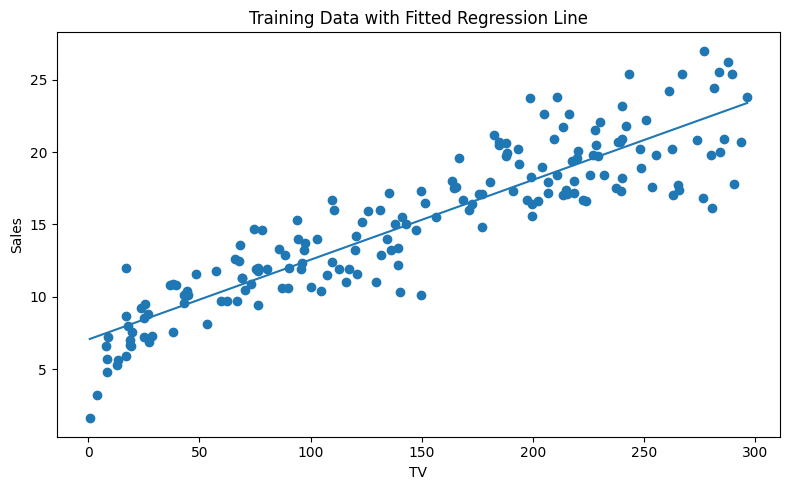

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(lr_train[chosen_feature], lr_train['Sales'])
sorted_train = lr_train.sort_values(chosen_feature)
line_x = sorted_train[chosen_feature].astype(float).tolist()
line_y = predict_simple_line(line_x, m, b)
plt.plot(line_x, line_y)
plt.xlabel(chosen_feature)
plt.ylabel('Sales')
plt.title('Training Data with Fitted Regression Line')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'linear_regression_plot.png'), dpi=200)
plt.show()


## Bonus Part 2E: Multiple Linear Regression

In [21]:
def fit_multiple_linear_regression(X, y):
    ones = np.ones((X.shape[0], 1))
    X_with_bias = np.hstack([ones, X])
    beta = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
    return beta

def predict_multiple_linear_regression(X, beta):
    ones = np.ones((X.shape[0], 1))
    X_with_bias = np.hstack([ones, X])
    return X_with_bias @ beta


In [22]:
multi_X_train = lr_train[['TV', 'Radio', 'Newspaper']].astype(float).values
multi_y_train = lr_train['Sales'].astype(float).values.reshape(-1, 1)
multi_X_test = lr_test[['TV', 'Radio', 'Newspaper']].astype(float).values
multi_y_test = lr_test['Sales'].astype(float).values.reshape(-1, 1)
beta = fit_multiple_linear_regression(multi_X_train, multi_y_train)
multi_predictions = predict_multiple_linear_regression(multi_X_test, beta).flatten().tolist()
multi_mse = calculate_mse(multi_y_test.flatten().tolist(), multi_predictions)
sk_multi = LinearRegression()
sk_multi.fit(multi_X_train, multi_y_train.flatten())
sk_multi_predictions = sk_multi.predict(multi_X_test).tolist()
sk_multi_mse = calculate_mse(multi_y_test.flatten().tolist(), sk_multi_predictions)
print('Intercept =', round(beta[0][0], 6))
print('TV coefficient =', round(beta[1][0], 6))
print('Radio coefficient =', round(beta[2][0], 6))
print('Newspaper coefficient =', round(beta[3][0], 6))
print('Manual multiple regression MSE =', round(multi_mse, 6))
print('Sklearn multiple regression MSE =', round(sk_multi_mse, 6))


Intercept = 4.741548
TV coefficient = 0.054067
Radio coefficient = 0.10306
Newspaper coefficient = 0.002408
Manual multiple regression MSE = 2.85838
Sklearn multiple regression MSE = 2.85838
